QUESTION 1 Take (or download) three images of the same well-lit indoor scene: one normal, one
deliberately under-exposed, and one over-exposed. Explain, using the radiometry and
digitization concepts from class, why the same scene produces such different pixel
value distributions.



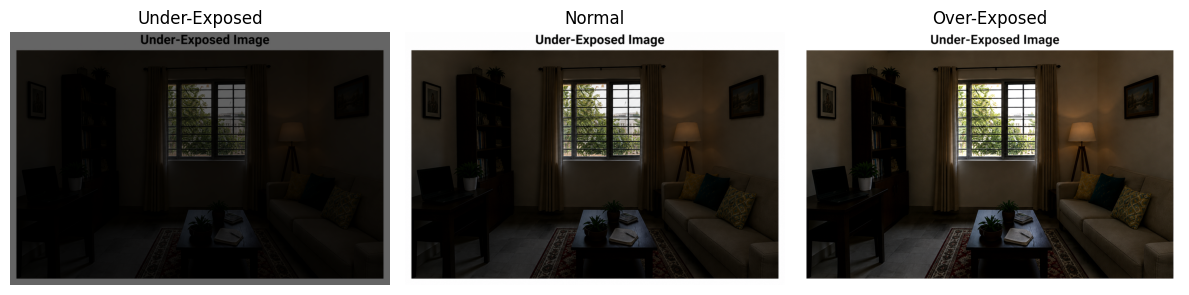

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Read image
img = cv2.imread("Under-exposed.png")

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load image 'Under-exposed.png'. Please ensure the file exists and the path is correct.")
else:
    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Convert to float for scaling
    img_float = img.astype(np.float32)

    # Create under-exposed and over-exposed versions
    under = np.clip(img_float * 0.4, 0, 255).astype("uint8")
    over = np.clip(img_float * 1.6, 0, 255).astype("uint8")

    images = [under, img, over]
    titles = ["Under-Exposed", "Normal", "Over-Exposed"]

    plt.figure(figsize=(12, 4))

    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.savefig("q1_exposure.png")
    plt.show()


EXPLANATION             

Exposure refers to the amount of light captured by the camera while taking an image. An under-exposed image receives insufficient light, so it appears dark and most of its pixels have low intensity values. A normally exposed image has a balanced amount of light, making the objects and details clearly visible. An over-exposed image receives too much light, making it very bright and causing some details to disappear. In an 8-bit grayscale image, pixel intensity values range from 0 to 255, where 0 represents black and 255 represents white. Therefore, changing the exposure changes the distribution of pixel intensity values in the image. The purpose of this experiment is to understand how different exposure levels affect image brightness and pixel-value distribution.

QUESTION 2     Simulate the CCTV's "grid artefact" complaint by writing your own 2D convolution
function (no library shortcuts) and running a low-pass (blur) and a high-pass (sharpen)
kernel over one of your images. Compare your output against OpenCV's built-in
filter2D to prove correctness.

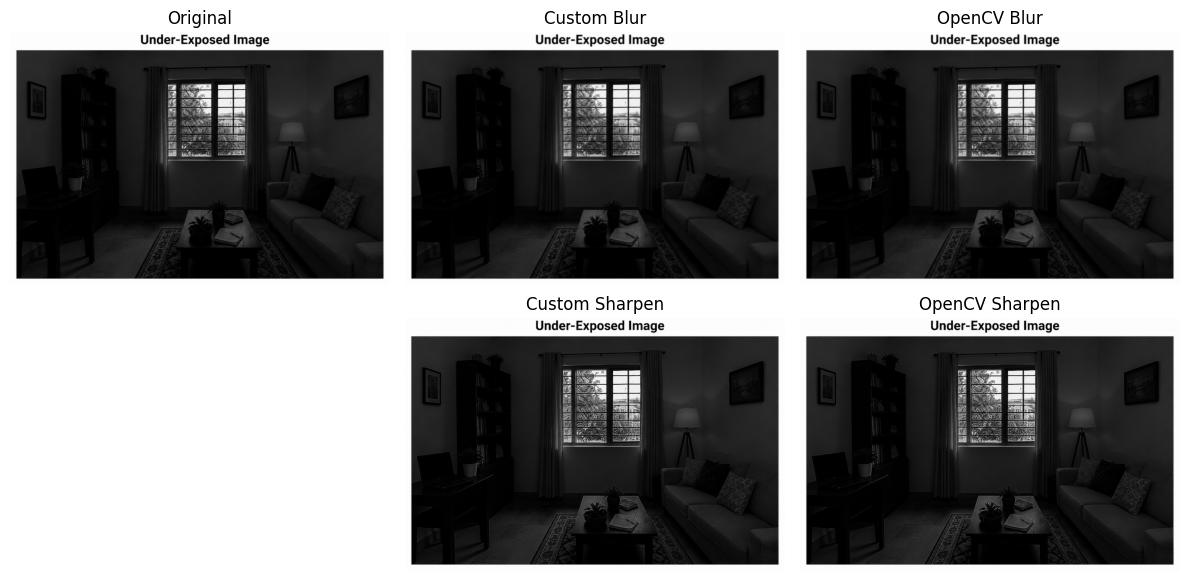

Blur difference: 0.4093468983968099
Sharpen difference: 0.0008379618326822916


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def convolution2d(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="edge"
    )

    output = np.zeros_like(image, dtype=np.float32)

    for i in range(h):
        for j in range(w):
            region = padded[i:i + kh, j:j + kw]
            output[i, j] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)


# Read image
img = cv2.imread("Under-exposed.png", cv2.IMREAD_GRAYSCALE)

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load image 'Under-exposed.png'.")
    print("Please ensure the image is in the same folder as this Python file.")

else:
    # Low-pass blur kernel
    blur_kernel = np.ones((3, 3), dtype=np.float32) / 9

    # High-pass sharpening kernel
    sharp_kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32)

    # Custom convolution
    blur_custom = convolution2d(img, blur_kernel)
    sharp_custom = convolution2d(img, sharp_kernel)

    # OpenCV results
    blur_cv = cv2.filter2D(img, -1, blur_kernel)
    sharp_cv = cv2.filter2D(img, -1, sharp_kernel)

    # Display results
    plt.figure(figsize=(12, 6))

    plt.subplot(2, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(blur_custom, cmap="gray")
    plt.title("Custom Blur")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(blur_cv, cmap="gray")
    plt.title("OpenCV Blur")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(sharp_custom, cmap="gray")
    plt.title("Custom Sharpen")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    plt.imshow(sharp_cv, cmap="gray")
    plt.title("OpenCV Sharpen")
    plt.axis("off")

    plt.tight_layout()

    # Save output
    plt.savefig("q2_convolution.png")

    # Show output
    plt.show()

    # Check correctness
    print(
        "Blur difference:",
        np.mean(
            np.abs(
                blur_custom.astype(float) -
                blur_cv.astype(float)
            )
        )
    )

    print(
        "Sharpen difference:",
        np.mean(
            np.abs(
                sharp_custom.astype(float) -
                sharp_cv.astype(float)
            )
        )
    )

EXPLANATION

2D convolution is an important operation in image processing in which a small matrix called a kernel or filter is applied over an image. The kernel moves across the image, and the corresponding pixel values are multiplied by the kernel values and added together to produce a new pixel value. In this experiment, a low-pass filter is used for blurring the image. It averages the neighboring pixels and reduces fine details and high-frequency components, resulting in a smoother image. A sharpening kernel is also applied to enhance edges and fine details, making the image appear clearer and sharper. A custom convolution function is implemented and its output is compared with the OpenCV filter2D() function. If both results are nearly the same, it confirms that the custom convolution implementation is working correctly.

QUESTION 3 Take the histogram of your under-exposed image, apply histogram equalization, and
write a short "incident report" (200–250 words) explaining, in a client-friendly tone,
why equalization improved visibility and what its limitations are.

/tmp/ipykernel_4864/289309482.py:30: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256])
/tmp/ipykernel_4864/289309482.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0, 256])


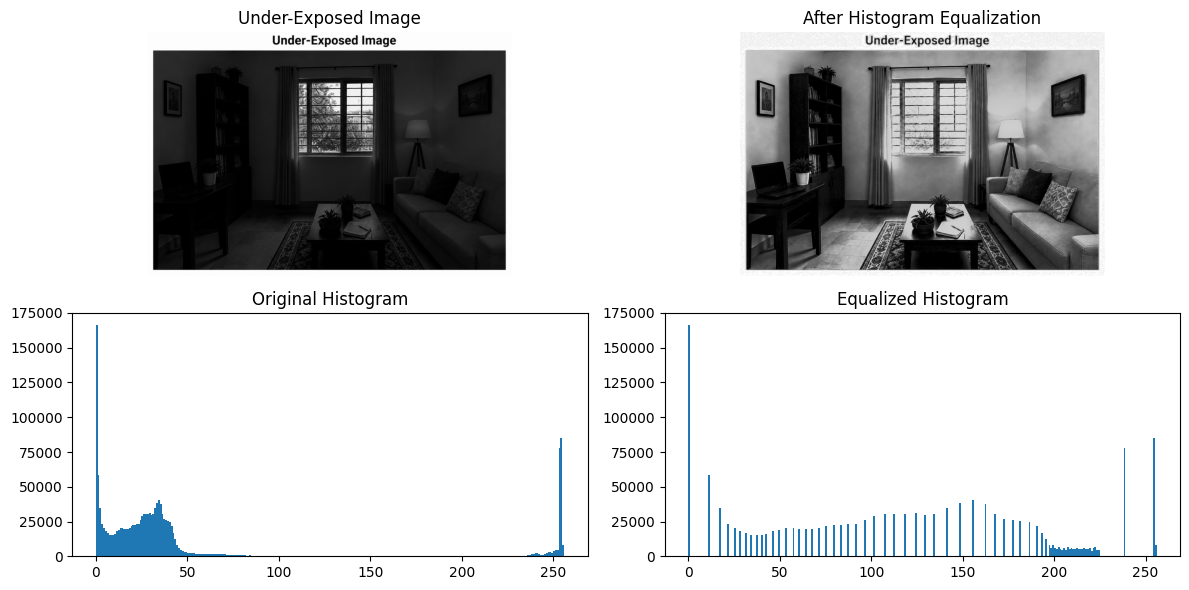

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Read under-exposed image
img = cv2.imread("Under-exposed.png", cv2.IMREAD_GRAYSCALE)

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load image 'Under-exposed.png'. Please ensure the file exists and the path is correct.")
else:
    # Histogram equalization
    equalized = cv2.equalizeHist(img)

    plt.figure(figsize=(12, 6))

    # Original image
    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Under-Exposed Image")
    plt.axis("off")

    # Equalized image
    plt.subplot(2, 2, 2)
    plt.imshow(equalized, cmap="gray")
    plt.title("After Histogram Equalization")
    plt.axis("off")

    # Original histogram
    plt.subplot(2, 2, 3)
    plt.hist(img.ravel(), 256, [0, 256])
    plt.title("Original Histogram")

    # Equalized histogram
    plt.subplot(2, 2, 4)
    plt.hist(equalized.ravel(), 256, [0, 256])
    plt.title("Equalized Histogram")

    plt.tight_layout()
    plt.savefig("q3_histogram.png")
    plt.show()

EXPLANATION

A histogram represents the distribution or frequency of different pixel intensity values present in an image. In an under-exposed image, most of the pixels are concentrated in the darker intensity range, which results in poor contrast and makes some details difficult to see. Histogram equalization is a technique used to improve the contrast of such an image by redistributing its intensity values over a wider range. After equalization, dark regions and other details can become more visible. However, histogram equalization cannot recover information that was completely lost during image capture and may sometimes increase noise. In this experiment, the histogram of the under-exposed image is studied before and after applying histogram equalization to observe the improvement in contrast.



QUESTION 4  Compute the 2D Fourier transform of one image, visualise the magnitude spectrum,
and use frequency-domain filtering to remove the suspected grid pattern (simulate it
by adding a synthetic periodic noise pattern to a clean image first, then remove it).

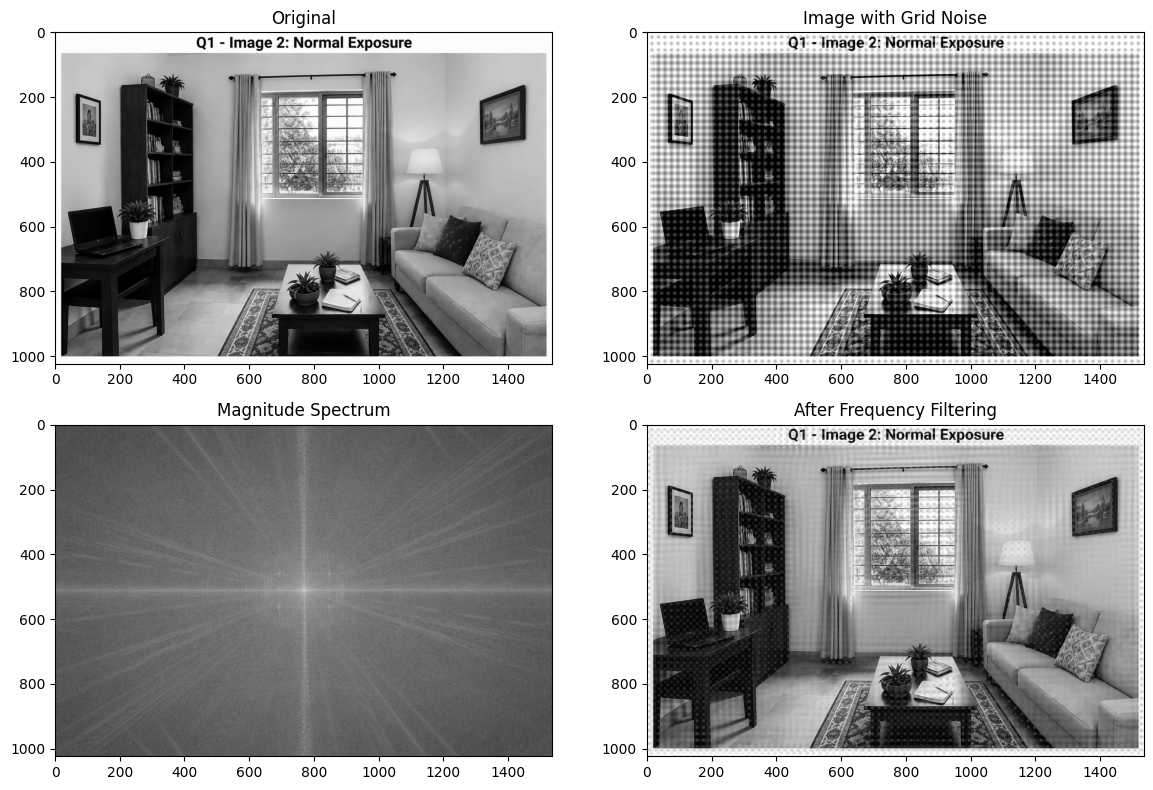

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("normal.png", cv2.IMREAD_GRAYSCALE)

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load image 'normal.png'. Please ensure the file exists and the path is correct.")
else:
    # Convert to float
    img_float = img.astype(np.float32)

    h, w = img.shape
    y, x = np.indices((h, w))

    # Synthetic periodic grid noise
    noise = 35 * (
        np.sin(2 * np.pi * x / 20) +
        np.sin(2 * np.pi * y / 20)
    )

    noisy = np.clip(img_float + noise, 0, 255).astype(np.uint8)

    # Fourier transform
    f = np.fft.fft2(noisy)
    fshift = np.fft.fftshift(f)

    magnitude = np.log(1 + np.abs(fshift))

    # Create notch-reject mask
    cy, cx = h // 2, w // 2
    mask = np.ones((h, w), np.uint8)

    radius = 8

    # Remove periodic frequency components
    for dx, dy in [(w//20, 0), (-w//20, 0),
                   (0, h//20), (0, -h//20)]:

        yy = cy + dy
        xx = cx + dx

        cv2.circle(mask, (xx, yy), radius, 0, -1)

    # Apply mask
    filtered = fshift * mask

    # Inverse Fourier transform
    result = np.fft.ifft2(np.fft.ifftshift(filtered))
    result = np.abs(result)

    result = np.clip(result, 0, 255).astype(np.uint8)

    # Display
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")

    plt.subplot(2, 2, 2)
    plt.imshow(noisy, cmap="gray")
    plt.title("Image with Grid Noise")

    plt.subplot(2, 2, 3)
    plt.imshow(magnitude, cmap="gray")
    plt.title("Magnitude Spectrum")

    plt.subplot(2, 2, 4)
    plt.imshow(result, cmap="gray")
    plt.title("After Frequency Filtering")

    plt.tight_layout()
    plt.savefig("q4_fourier.png")
    plt.show()

EXPLANATION

The Fourier Transform is used to convert an image from the spatial domain into the frequency domain. In the spatial domain, an image is represented by individual pixels, whereas in the frequency domain, it is represented using different frequency components. Low-frequency components generally represent smooth regions and gradual changes, while high-frequency components represent edges, fine details and some types of noise. In this experiment, a periodic grid pattern is added to the image as artificial noise. Because the grid pattern is repetitive, it produces distinct peaks in the Fourier frequency spectrum. These unwanted frequency components can be identified and removed using a notch-reject filter. Finally, the inverse Fourier Transform converts the filtered frequency-domain image back into the spatial domain, producing a cleaner image.



QUESTION 5 Finally, apply a rigid transformation (rotation + translation) and an affine
transformation to one image and explain, geometrically, which one a camera
undergoing pure panning would produce versus one mounted on a slightly warped
bracket.

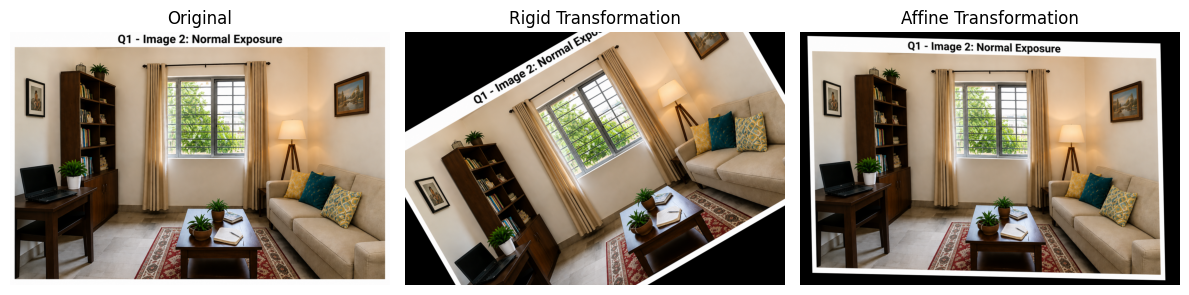

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("normal.png")

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load image 'normal.png'. Please ensure the file exists and the path is correct.")
else:
    h, w = img.shape[:2]

    # -----------------------------
    # Rigid Transformation
    # -----------------------------

    center = (w // 2, h // 2)

    # Rotation by 30 degrees
    M_rotation = cv2.getRotationMatrix2D(
        center, 30, 1.0
    )

    # Add translation
    M_rotation[0, 2] += 40
    M_rotation[1, 2] += 20

    rigid = cv2.warpAffine(
        img, M_rotation, (w, h)
    )

    # -----------------------------
    # Affine Transformation
    # -----------------------------

    src = np.float32([
        [0, 0],
        [w-1, 0],
        [0, h-1]
    ])

    dst = np.float32([
        [30, 20],
        [w-80, 50],
        [50, h-50]
    ])

    M_affine = cv2.getAffineTransform(src, dst)

    affine = cv2.warpAffine(
        img, M_affine, (w, h)
    )

    # Display
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(rigid, cv2.COLOR_BGR2RGB))
    plt.title("Rigid Transformation")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(affine, cv2.COLOR_BGR2RGB))
    plt.title("Affine Transformation")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig("q5_transformations.png")
    plt.show()

EXPLANATION

Geometric transformations are used to change the position, orientation or geometry of an image. A rigid transformation mainly involves rotation and translation. Rotation changes the orientation of the image, while translation moves the image from one position to another. A rigid transformation preserves the shape, angles and distances of objects. An affine transformation is more flexible and can include rotation, translation, scaling and shearing. It can change the size or appearance of an object while preserving straight lines and parallel relationships. In this experiment, both rigid and affine transformations are applied to an image and their effects are observed. A rigid transformation can represent simple camera movement such as panning, while an affine transformation is more suitable for situations involving scaling, shearing or slight geometric distortion.

